# Final touch to the assembly before polishing

This Jupyter notebook will guide you on how to create a cleaner assembly after rerunning Verkko to fill some gaps and before proceeding to the polishing step. This includes contig trimming, chromosome flipping, and chromosome renaming.

In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload



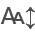

In [9]:
import sys 
import importlib
import pandas as pd
import time
import os
from IPython.display import Image, display
pd.set_option('mode.chained_assignment', None)
from itables import init_notebook_mode
init_notebook_mode(all_interactive=True)
import warnings
import session_info
# Suppress FutureWarnings
sys.path.append('/data/Phillippy/projects/giraffeT2T/assembly/script/verkko-fillet/src')
warnings.simplefilter(action='ignore', category=FutureWarning)

In [10]:
import verkkofillet as vf
# importlib.reload(vf)

verkko-fillet version:0.1.24


## Load data

In [13]:
verkkoDir="/path/to/your/folder/verkko2.2_hifi-duplex_trio-hic/verkko-thic_v0.8.0"

In [17]:
obj = vf.pp.read_Verkko(verkkoDir)

The Verkko fillet target directory already exists: /path/to/your/folder/verkko2.2_hifi-duplex_trio-hic/verkko-thic_v0.8.0_verkko_fillet
If you didn't mean this, please set another directory or for overwirting, please use force= True
Lock the original Verkko folder to prevent it from being modified.
[lock_original_folder] Command executed successfully!
change working directory: /path/to/your/folder/verkko2.2_hifi-duplex_trio-hic/verkko-thic_v0.8.0_verkko_fillet
Path file loaded successfully.
scfmap file loaded successfully.
File 8-hicPipeline/final_contigs/assembly.ont-coverage.csv not found
File 8-hicPipeline/final_contigs/assembly.hifi-coverage.csv not found
Reading assembly.homopolymer-compressed.noseq.gfa
Number of nodes read from graph: 2755
Reading assembly.colors.csv
Number of nodes read from graph: 2755
Number of nodes read from graph: 2755
Node information is stored in obj.node


In [18]:
obj

FilletObj
  verkkoDir: /path/to/your/folder/verkko2.2_hifi-duplex_trio-hic/verkko-thic_v0.8.0
  verkko_fillet_dir: /path/to/your/folder/verkko2.2_hifi-duplex_trio-hic/verkko-thic_v0.8.0_verkko_fillet
  paths: name, path, assignment, gaps, rm
  history: timestamp, activity, function
  scfmap: contig, pathName
  node: node, len, mat, pat, mat:pat, color
  edge: node1, node1_strand, node2, node2_strand, overlap

## Make stats

In [8]:
%%time
vf.tl.getT2T(obj)

getT2T was done!
CPU times: user 2.26 ms, sys: 6.25 ms, total: 8.51 ms
Wall time: 6.86 s


In [28]:
ref_fasta = "/path/to/your/folder/ncbiRef/GCA_017591445.1_ASM1759144v1_genomic.rename.fa"
map_file="/path/to/your/folder/giraffe.chrMap"

In [37]:
%%time
ref = "/path/to/your/folder/ncbiRef/GCA_017591445.1_ASM1759144v1_genomic.rename.fa"
vf.tl.chrAssign(obj = obj, ref = ref)

The [assembly.mashmap.out] file is already exists
If you want to re-run this job, please detete [assembly.mashmap.out]
CPU times: user 217 µs, sys: 87 µs, total: 304 µs
Wall time: 391 µs


In [30]:
obj = vf.pp.readChr(obj, map_file)

Haplotype names not provided, using default haplotype identifiers.
The chromosome infomation was stored in obj.stats


File figs/contigPlot.heatmap.pdf saved


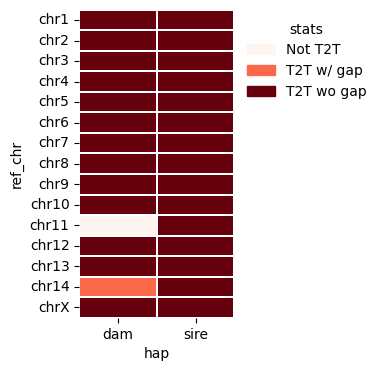

In [31]:
vf.pl.contigPlot(obj)

## Trimming

In [32]:
vf.tl.detect_internal_telomere(obj)
result_merged, tel = vf.pp.find_intra_telo(obj, loc_from_end=18000)
result_merged

Starting detecting internal telomere in the assembly.fasta
All output files already exist. Skipping internal telomere detection.
Finding the internal telomeres in the assembly...
Reading file: /path/to/your/folder/verkko2.2_hifi-duplex_trio-hic/verkko-thic_v0.8.0_verkko_fillet/internal_telomere/assembly_1/assembly.windows
Number of internal telomeres: 3
Merging with stats database...
File saved: /path/to/your/folder/verkko2.2_hifi-duplex_trio-hic/verkko-thic_v0.8.0_verkko_fillet/internal_telomere/assembly_1/assembly.windows.loc_from_end_18000.teloPerct_0.5.telolen_0.stats.tsv


contig  distal-left  distal-right  \
0    dam_compressed.k31.hapmer-0000009          1.0           1.0   
1   sire_compressed.k31.hapmer-0000027          1.0           1.0   
2    dam_compressed.k31.hapmer-0000005          1.0           1.0   
3   sire_compressed.k31.hapmer-0000023          1.0           1.0   
4    dam_compressed.k31.hapmer-0000002          0.0           1.0   
5   sire_compressed.k31.hapmer-0000020          1.0           1.0   
6    dam_compressed.k31.hapmer-0000010          1.0           1.0   
7   sire_compressed.k31.hapmer-0000028          1.0           1.0   
8    dam_compressed.k31.hapmer-0000011          1.0           1.0   
9   sire_compressed.k31.hapmer-0000029          1.0           1.0   
10   dam_compressed.k31.hapmer-0000008          1.0           1.0   
11  sire_compressed.k31.hapmer-0000026          1.0           1.0   
12   dam_compressed.k31.hapmer-0000003          1.0           1.0   
13  sire_compressed.k31.hapmer-0000021          1.0           1.0   
14   dam_compressed.k31.hapmer-0000015          1.0           1.0   
15  sire_compressed.k31.hapmer-0000033          1.0           1.0   
16   dam_compressed.k31.hapmer-0000006          1.0           1.0   
17  sire_compressed.k31.hapmer-0000024          1.0           1.0   
18   dam_compressed.k31.hapmer-0000001          1.0           1.0   
19  sire_compressed.k31.hapmer-0000019          1.0           1.0   
20   dam_compressed.k31.hapmer-0000004          1.0           1.0   
21  sire_compressed.k31.hapmer-0000022          1.0           1.0   
22   dam_compressed.k31.hapmer-0000012          1.0           1.0   
23  sire_compressed.k31.hapmer-0000030          1.0           1.0   
24   dam_compressed.k31.hapmer-0000013          1.0           1.0   
25  sire_compressed.k31.hapmer-0000031          1.0           1.0   
26   dam_compressed.k31.hapmer-0000014          1.0           1.0   
27  sire_compressed.k31.hapmer-0000032          1.0           1.0   
28   dam_compressed.k31.hapmer-0000007          1.0           1.0   
29  sire_compressed.k31.hapmer-0000025          1.0           1.0   

    internal-left  internal-right           problem ref_chr  contig_len  \
0           0.000           0.000          OK/INTEL    chr1   227014932   
1           0.000           0.000          OK/INTEL    chr1   236983059   
2           0.000           0.000          OK/INTEL   chr10   162004027   
3           0.000           0.000          OK/INTEL   chr10   161568982   
4           0.998           0.000  MissingTel/INTEL   chr11   152383474   
5           0.000           0.000          OK/INTEL   chr11   150900004   
6           0.000           0.000          OK/INTEL   chr12   147919805   
7           0.000           0.000          OK/INTEL   chr12   150165282   
8           0.000           0.000          OK/INTEL   chr13   124363021   
9           0.000           0.000          OK/INTEL   chr13   123819179   
10          0.000           0.000          OK/INTEL   chr14    75183107   
11          0.000           0.000          OK/INTEL   chr14    72983736   
12          0.000           0.000          OK/INTEL    chr2   239044151   
13          0.000           0.000          OK/INTEL    chr2   238229772   
14          0.000           0.000          OK/INTEL    chr3   192562690   
15          0.000           0.000          OK/INTEL    chr3   193438326   
16          0.000           0.522          OK/INTEL    chr4   212706385   
17          0.000           0.511          OK/INTEL    chr4   212213245   
18          0.000           0.000          OK/INTEL    chr5   194161755   
19          0.000           0.000          OK/INTEL    chr5   194525582   
20          0.000           0.000          OK/INTEL    chr6   179095105   
21          0.000           0.000          OK/INTEL    chr6   178486878   
22          0.000           0.000          OK/INTEL    chr7   161659383   
23          0.000           0.000          OK/INTEL    chr7   162115183   
24          0.000

File figs/intra_telo.heatmap.pdf already exists
Please remove the file or change the name


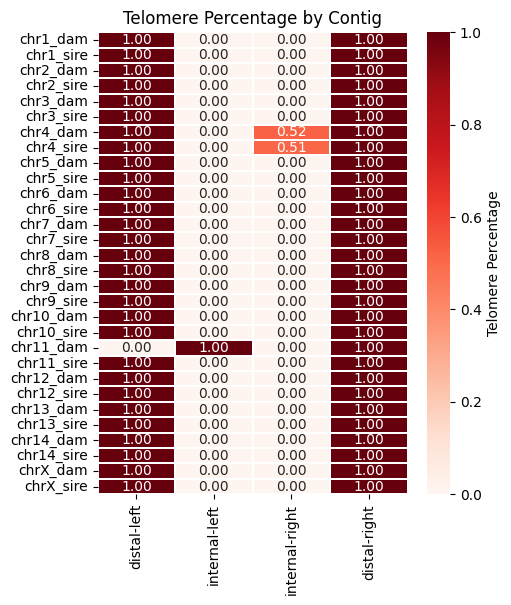

In [39]:
vf.pl.percTel(result_merged, showContig  = ['ref_chr','hap'], height = 6, width = 5)

In [35]:
tel.loc[tel['tel-arm'].str.contains('internal')]

contig   totalLen      start        end  \
2    dam_compressed.k31.hapmer-0000002  152383488      18800      29000   
11   dam_compressed.k31.hapmer-0000006  212706432  212568200  212569200   
43  sire_compressed.k31.hapmer-0000024  212213248  212075200  212076200   

    teloPerct  telomere    arm    len         tel-arm  
2       0.998  internal   left  10200   internal-left  
11      0.522  internal  right   1000  internal-right  
43      0.511  internal  right   1000  internal-right

In [38]:
# chr11 dam haplotype

tel_piece , df = vf.pp.find_reads_intra_telo(obj, tel, 2 ,scfmap = "assembly.scfmap")
# tel_piece

Finding the reads support for the additional artifical sequences outside of the telomere...
Using layout file: /path/to/your/folder/verkko2.2_hifi-duplex_trio-hic/verkko-thic_v0.8.0/6-layoutContigs/unitig-popped.layout
Looking for the reads from start of dam_compressed.k31.hapmer-0000002
the piece of interest is from 0 to 152383488, match piece is piece000002
the piece length is 152383488, the piece length in hpc is 107434201
Summary : 
   Num of ONT reads : 3
   Num of HiFi reads : 0
   Num of ONT corrected reads : 0


This result indicates that the left end of the contig is supported only by ONT reads and lacks HiFi read support. This region is therefore a candidate for trimming, although additional evidence should be considered before making a final decision.

In [ ]:
trim_contig_dict = {
    'dam_compressed.k31.hapmer-0000002' : [(18800, 152383488)],  # chr11 dam haplotype from start of the internal telo to the end of the contig
    # 'haplotype2-0000064': [(30200, 133974464)],
}

In [17]:
vf.tl.runTrimming(obj, trim_contig_dict)

Trim Chromosomes:   0%|                         | 1/253 [00:00<02:19,  1.80it/s]

dam_compressed.k31.hapmer-0000002 will be trimmed
samtools faidx assembly.fasta dam_compressed.k31.hapmer-0000002:18800-152521440 | sed -e '1d' | sed -e '1i >dam_compressed.k31.hapmer-0000002'>> assembly_trimmed.fasta


Trim Chromosomes: 100%|███████████████████████| 253/253 [00:15<00:00, 16.18it/s]

Trimming completed. Output file: assembly_trimmed.fasta


## Flipping chromosome

If your species already has a reference genome, you can examine the orientation of your assembly. If the orientation is flipped, you can adjust (flip) specific chromosomes as needed. However, it is important to ensure that the previous reference genome was carefully curated for orientation. To confirm this, you can review the methods section in the original publication associated with the released reference genome or other relevant documentation.

output
* `assembly.mashmap.out`
* `assembly.homopolymer-compressed.chr.csv`
* `unitigs.hpc.mashmap.out`
* `translation_hap1`
* `translation_hap2`
* `chr_completeness_max_hap1`
* `chr_completeness_max_hap2`

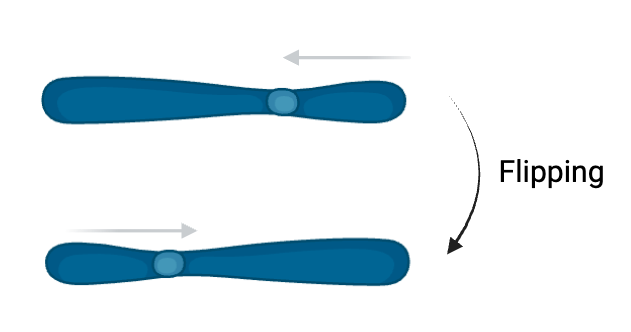

In [7]:
image_path = "/path/to/your/folder/script/post_verkko_pkg/data/test_giraffe/fig/chromosomeFlipping.png"
display(Image(filename=image_path,width=400))

[showPairwiseAlign_1] Command executed successfully!
[showPairwiseAlign_2] Command executed successfully!


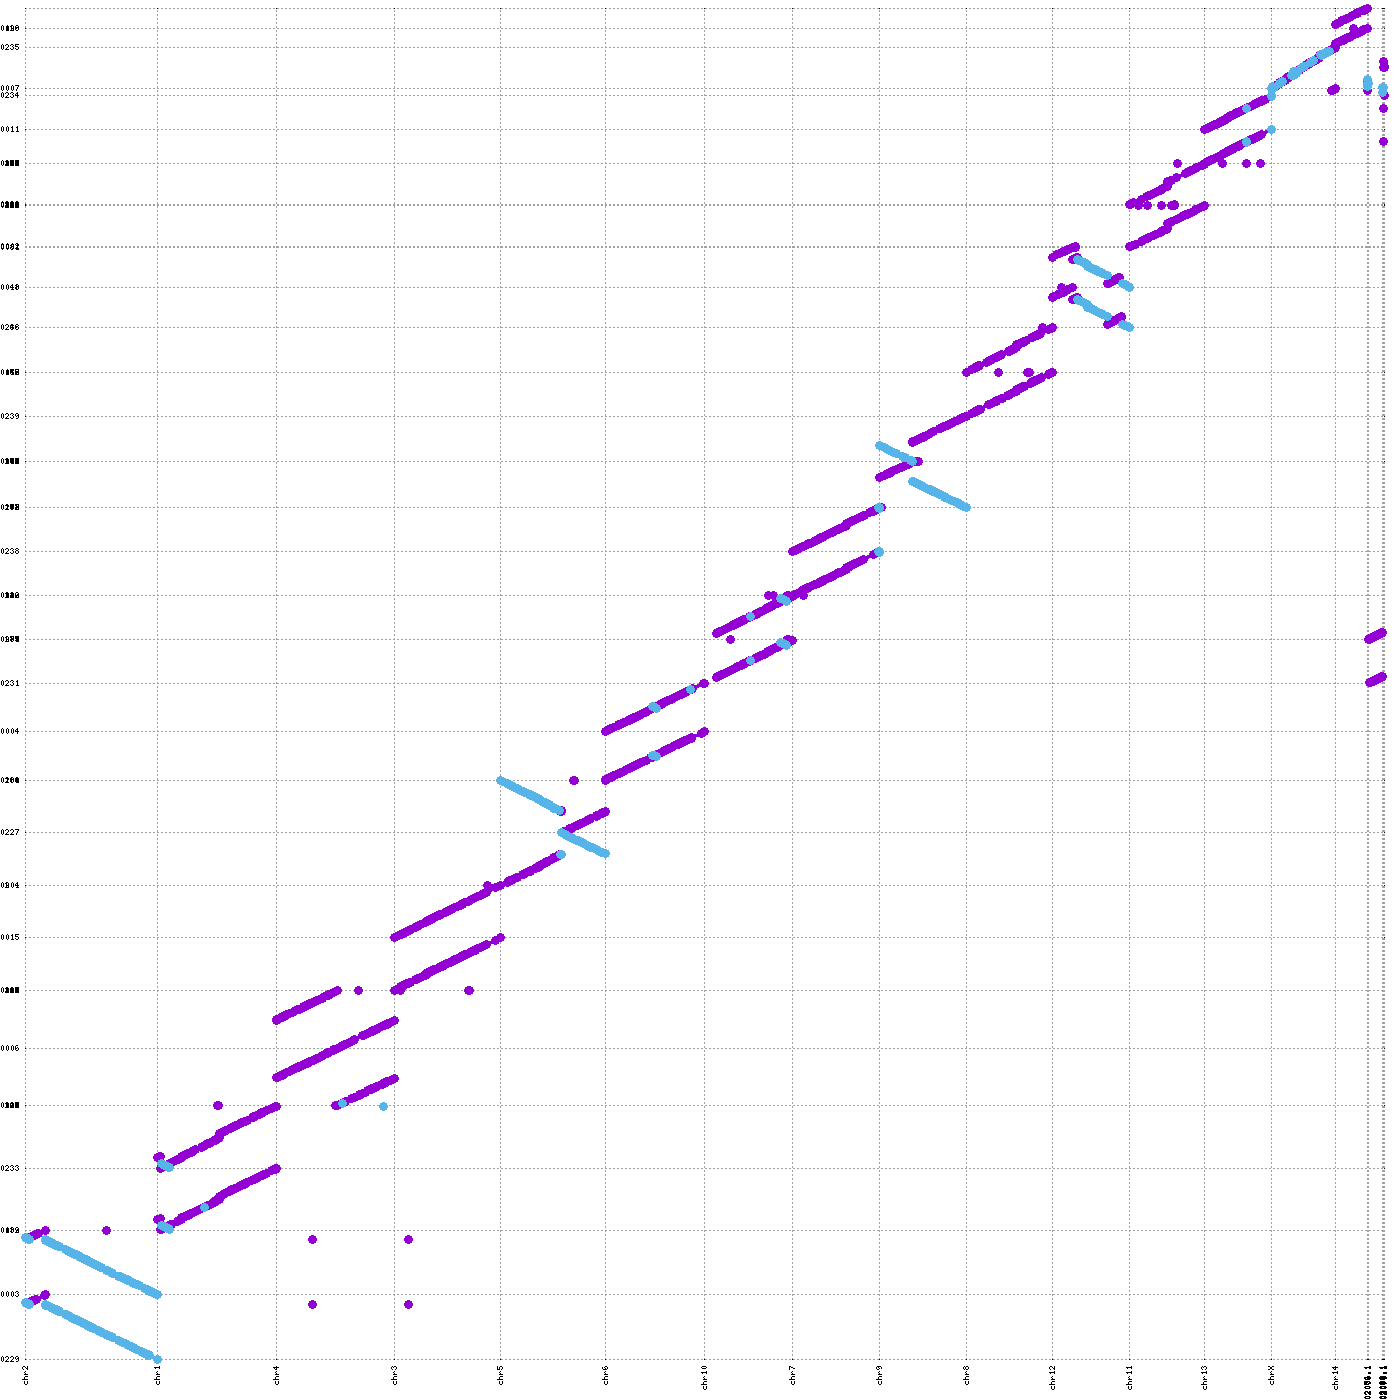

In [307]:
vf.tl.showPairwiseAlign(obj, size="large", minLen = 100000)

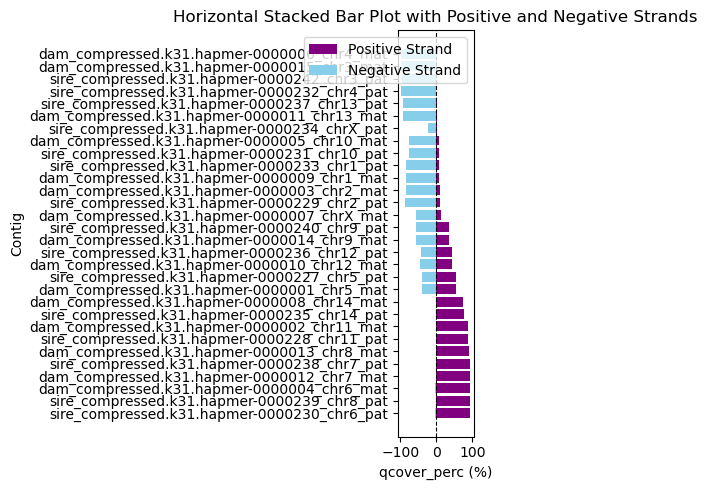

In [308]:
vf.pl.showMashmapOri(obj , by = 'all')

The `vf.tl.flipChr()` function flips the original FASTA file using the list of chromosomes, flip_contig_list. The final FASTA file will be generated with the suffix `_flipped.fasta`.

In [ ]:
flip_contig_list = vf.tl.find_flip_candidates(obj)
vf.tl.flipContig(flip_contig_list, 
              ori_fasta="assembly_trimmed.fasta",
              final_fasta="assembly_trimmed_flipped.fasta")

Flipping Chromosomes: 100%|███████████████████| 253/253 [00:58<00:00,  4.31it/s]

The chromosome flipping was completed successfully!
Output FASTA: assembly_trimmed_flipped.fasta


## Renaming Primary and Other Small Contigs with Chromosome Information and Haplotype

We will rename contigs using patterns such as [chr]\_[hap] for primary chromosomes and [chr]\_[hap]\_random\_[node] for random contigs, where node represents a representative node in the path. You can trace back the original paths later.
                  
* chr: chr1, chr2, chr3, ... UnChr
* hap: mat, pat, or Unhap

`vf.pp.find_multi_used_node()` identifies nodes that are used by more than one chromosome. We will exclude these nodes when clustering nodes by chromosome using link information from the GFA file.


You will get two outputs:

* `duplicate_nodes`: A list of nodes used in different chromosomes.
* `node_database`: A dataframe with two columns ("chromosome" and "nodeSet"), containing the set of nodes used exclusively in the corresponding chromosome.

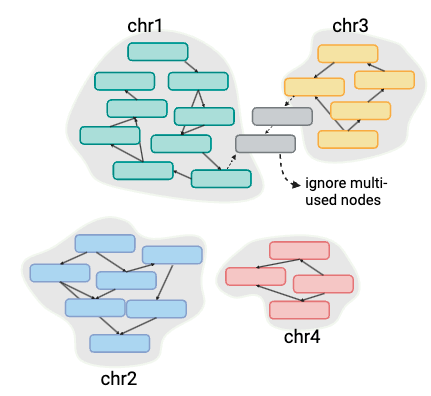

In [6]:
image_path = "/path/to/your/folder/script/post_verkko_pkg/data/test_giraffe/fig/nodeClustering.png"
display(Image(filename=image_path,width=400))

In [57]:
duplicate_nodes, node_database = vf.pp.find_multi_used_node(obj)
# duplicates, node_database = vf.pp.find_multi_used_node(obj)
duplicate_nodes

['utig4-1759', 'utig4-1805', 'utig4-1757']

`The vf.pp.naming_contigs()` function uses the FAI index of assembly.fasta located in the `obj.verkkoDir` directory, along with `obj.paths` and `obj.scfmap`, to assign the corresponding chromosome and haplotype to non-primary contigs.

In [58]:
chrMap = vf.pp.naming_contigs(obj, node_database, duplicate_nodes)

component_15 : empty


In [61]:
chrMap

contig            new_contig_name
0     dam_compressed.k31.hapmer-0000001                   chr5_mat
1     dam_compressed.k31.hapmer-0000002                  chr11_mat
2     dam_compressed.k31.hapmer-0000003                   chr2_mat
3     dam_compressed.k31.hapmer-0000004                   chr6_mat
4     dam_compressed.k31.hapmer-0000005                  chr10_mat
..                                  ...                        ...
218  sire_compressed.k31.hapmer-0000332  chr1_pat_random_utig4-844
219  sire_compressed.k31.hapmer-0000335    chr8_pat_random_utig4-9
220  sire_compressed.k31.hapmer-0000336   chr8_pat_random_utig4-92
221  sire_compressed.k31.hapmer-0000337   chr8_pat_random_utig4-94
222  sire_compressed.k31.hapmer-0000338   chr8_pat_random_utig4-95

[253 rows x 2 columns]

If you have made any changes to the chromosome naming, please edit the chrMap directly before using `vf.tl.renameContig()`.

In [60]:
chrMap['new_contig_name'] = chrMap['new_contig_name'].replace('chrX_pat', 'chrY_pat')

This is the final step. Using the dataframe obtained above, we can rename the contigs using `vf.tl.renameContig()`. The final FASTA file will be generated with the suffix `_rename.fasta`.

In [62]:
vf.tl.renameContig(obj, chrMap, original_fasta="assembly_trimmed_flipped.fasta")

[chrRename] Command executed successfully!
Final renamed fasta file : assembly_trimmed_flipped_rename.fasta


## Sort

Before polishing, we will sort the contigs either by chr or by hap:
* by `hap`: Contigs will be sorted by chromosome within haplotype. For example: chr1_mat > chr2_mat > chr3_mat > ... > chrX_mat > chr1_pat > chr2_pat > ... > chr1_mat_random_utig4-10 > ...
* by `chr`: Contigs will be sorted by haplotype within chromosome. For example: chr1_mat > chr1_pat > chr2_mat > chr2_pat > ... > chr1_mat_random_utig4-10 > ...

The default mode is `sort_by="hap"`. You can use `sort_by="chr"`, but hap sorting is better when viewing the assembly in IGV.

In [63]:
vf.tl.sortContig("assembly_trimmed_flipped_rename.fasta", sort_by="hap")

Sorted sequences have been written to assembly_trimmed_flipped_rename_sortedhap.fasta


## Merging and resizing rDNA gaps 

If there are more than two gaps within an rDNA array, we can merge them into a single gap because the sequences between the gaps are known. This is a special case for rDNA arrays that allows us to simplify the assembly.

`vf.tl.rDNA_gap_cleaning` consists of three steps:

1. Align the 45S rDNA sequence to the assembly to identify rDNA locations.
2. Find gaps in the assembly and determine whether each gap is bounded by rDNA units.
3. Generate a new assembly by adjusting the gap sizes for gaps within rDNA arrays and merging multiple gaps into a single gap when they are bounded by rDNA units.


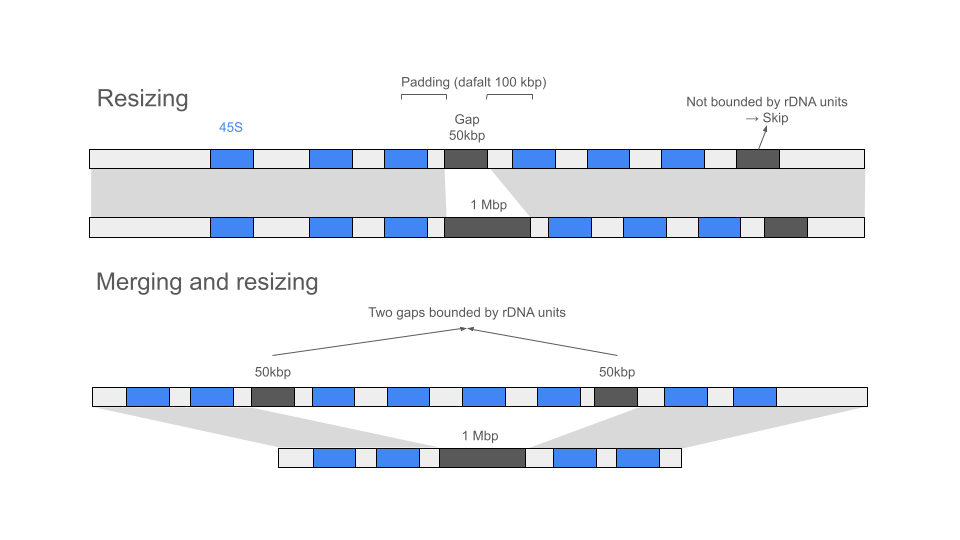

In [25]:
image_path = "/path/to/your/folder/script/verkko-fillet/docs/figs/rDNA_cleaning.png"
display(Image(filename=image_path,width=400))

In [22]:
vf.tl.rDNA_gap_cleaning(fasta = "assembly_trimmed_flipped_rename_sortedhap.fasta", 
                        gap_rDNA_info = "assembly_trimmed_flipped_rename_sortedhap.gaps.bed.rDNA.bounded.csv", 
                        out_fasta = None, 
                        gap_size=100000, padding = 100_000, idx = 90, threads=10,
                        force=False)

fasta input : assembly_trimmed_flipped_rename_sortedhap.fasta
rDNA reference sequence: /data/Phillippy/projects/giraffeT2T/assembly/script/verkko-fillet/src/verkkofillet/data/dataset/NT_167214.1.fa
Align rDNA on fasta file ... 
rDNA mapping file already exists: rDNA_mapping/45S.mashmap.bed
Gaps file already exists: assembly_trimmed_flipped_rename_sortedhap.gaps.bed
Finding gaps in rDNA mapping for assembly_trimmed_flipped_rename_sortedhap.fasta with padding of 100000 bp and idx threshold of 90 ...
Gap 0 on chr14_mat (13199831-13207331) is bounded by rDNA within 100000 bp.
Gap analysis completed. Results saved to assembly_trimmed_flipped_rename_sortedhap.gaps.bed.rDNA.bounded.csv
Cleaning gaps in rDNA regions for assembly_trimmed_flipped_rename_sortedhap.fasta with gap size of 100000 ...
Output FASTA will be saved to: assembly_trimmed_flipped_rename_sortedhap_rDNA_gap_cleaned.fasta


[+] Loading samtools 1.23  ... 
[+] Loading seqtk  1.5 


Processing contig: chr1_mat
Progress: [#                                       ]   3% (1/33)Processing contig: chr2_mat
Progress: [##                                      ]   6% (2/33)Processing contig: chr3_mat
Progress: [###                                     ]   9% (3/33)Processing contig: chr4_mat
Progress: [####                                    ]  12% (4/33)Processing contig: chr5_mat
Progress: [######                                  ]  15% (5/33)Processing contig: chr6_mat
Progress: [#######                                 ]  18% (6/33)Processing contig: chr7_mat
Progress: [########                                ]  21% (7/33)Processing contig: chr8_mat
Progress: [#########                               ]  24% (8/33)Processing contig: chr9_mat
Progress: [##########                              ]  27% (9/33)Processing contig: chr10_mat
Progress: [############                            ]  30% (10/33)Processing contig: chr11_mat
Progress: [#############                         